In [1]:
import sys
sys.path.append('./models/')
from Model import Model
from Arima import ARIMA_Model, VAR_m
from exponential_regression import ExponentialRegression, MultiDimensionalExponentialRegression
from SIRH  import *
from LinearRegression import *
from BayesianRegression import *
from moving_average import MovingAverage, MovingAverageMulti
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from evaluate_model import evaluate_model, evaluate_model_multi, evaluate_model_multi_RMSE, evaluate_model_RMSE
import json
import warnings
#warnings.filterwarnings('ignore')
warnings.filterwarnings(action='once')

In [2]:
#For plotting lines with colour gradients
from collections import deque
from itertools import islice
from matplotlib import collections as mc
from matplotlib.colors import colorConverter

In [3]:
def sliding_window(iterable, n):
  """
  sliding_window('ABCDEFG', 4) -> ABCD BCDE CDEF DEFG
  
  recipe from python docs
  """
  it = iter(iterable)
  window = deque(islice(it, n), maxlen=n)
  if len(window) == n:
      yield tuple(window)
  for x in it:
      window.append(x)
      yield tuple(window)

In [4]:
def color_gradient(x, y, c1, c2):
  """
  Creates a line collection with a gradient from colors c1 to c2,
  from data x and y.
  """
  n = len(x)
  if len(y) != n:
    raise ValueError('x and y data lengths differ')
  return mc.LineCollection(sliding_window(zip(x, y), 2),
                           colors=np.linspace(colorConverter.to_rgb(c1),
                                              colorConverter.to_rgb(c2), n - 1))

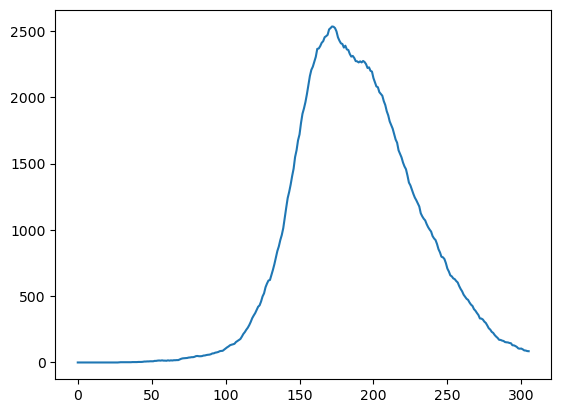

In [50]:
df=pd.read_csv('./all_pandemics/pandemic_0_4.csv')
df.index=['n_hospitalized', 'n_infectious', 'mobility', 'R_eff']
df.drop(columns=['Unnamed: 0'], inplace=True)
n_hospitalized=np.array(df.loc['n_hospitalized'])
n_infectious=np.array(df.loc['n_infectious'])
mobility=np.array(df.loc['mobility'])
plt.plot(n_hospitalized)

In [12]:
alpha=0.05 #Confidence interval at 100(1-alpha)%

myma=MovingAverage()
myarima=ARIMA_Model()
mybayes=BayesianRegressionModel()
mylinear=LinearRegressionModel()
myvar=VAR_m()

myexp=ExponentialRegression()
myexpmulti=MultiDimensionalExponentialRegression()

mysirh1=SIRH_model_2()
mysirh1.choose_model(True, True, False)
mysirh2=SIRH_model_2()
mysirh2.choose_model(True, False, False)
mysirh3=SIRH_model_2()
mysirh3.choose_model(False, True, False)
mysirh4=SIRH_model_2()
mysirh4.choose_model(False, False, False)

mysirh_multi1=Multi_SIRH_model()
mysirh_multi1.choose_model(True)

mysirh_multi2=Multi_SIRH_model()
mysirh_multi2.choose_model(False)

myseir=SEIR_model()

In [13]:
def generate_prediction(model: Model, data: np.array, alpha: int, start: int, horizon: int, threeD: bool):
    if threeD:
        n_hospitalized_trunc=data[0][:start]
        n_infectious_trunc=data[1][:start]
        mobility_smoothed_trunc=data[2][:start]
        model.train(train_dates = [i for i in range(start)], data = np.array([n_hospitalized_trunc, n_infectious_trunc, mobility_smoothed_trunc]))
    else:
        n_hospitalized_trunc=data[0][:start]
        model.train(train_dates = [i for i in range(start)], data=n_hospitalized_trunc)
    #intervals=[]
    #reach=[i for i in range(1, horizon)]
    #predict=[]
    prediction, interval = model.predict(horizon, alpha)
    return interval, prediction

20
40
60
80
100
120
140
160
180
200
220
240
260
280


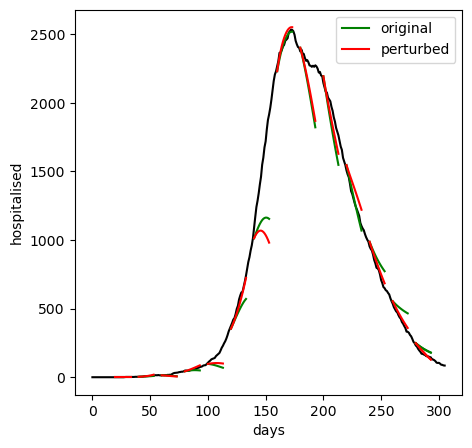

In [55]:
frequency=20
n = len(mobility)
reps = mobility[::frequency]
mobility_np = np.repeat(reps, frequency)
data3Dp=np.array([n_hospitalized, n_infectious, mobility_np[:n]])
data3D=np.array([n_hospitalized, n_infectious, mobility])

start_dates=[(20*i) for i in range(1,15)]
#start_dates=[150,200]
horizon=14
fig, ax = plt.subplots(figsize=(5,5))
ax.plot(n_hospitalized,'k')
for S in start_dates:
    print(S)
    CI, predict=generate_prediction(model=myseir, data=data3D, alpha=alpha, start=S, horizon=horizon,threeD=True)
    CIp, predictp=generate_prediction(model=myseir, data=data3Dp, alpha=alpha, start=S, horizon=horizon,threeD=True)
    dates=np.arange(S,S+horizon)
    ci=np.asarray(CI)
    #plt.fill_between(dates,ci[0,:], ci[1,:], color='black', alpha=.3, label='95% confidence interval')
    plt.plot(dates,predict,'g')
    cip=np.asarray(CIp)
    #plt.fill_between(dates,cip[0,:], cip[1,:], color='black', alpha=.3, label='95% confidence interval')
    plt.plot(dates,predictp,'r')
plt.plot(dates,predict,'g',label='original')
plt.plot(dates,predictp,'r',label='perturbed')
plt.ylabel('hospitalised')
plt.xlabel('days')
plt.legend()
plt.savefig('output.pdf')

In [54]:
plt.savefig('output.pdf')

<Figure size 640x480 with 0 Axes>